In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive Mounted Successfully")

Mounted at /content/drive
Google Drive Mounted Successfully


In [ ]:
import json

data = {
    "username": "keertitimmanabhat",
    "key": "KGAT_db9ae37571af301b3fffacc1a438312f"
}

with open("kaggle.json", "w") as f:
    json.dump(data, f)

print("kaggle.json file created")

kaggle.json file created


In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json","/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json",600)

print("Kaggle setup complete")

Kaggle setup complete


In [ ]:
!kaggle datasets download -d nabilsherif/oil-spill

print("Dataset Downloaded from Kaggle")

Dataset URL: https://www.kaggle.com/datasets/nabilsherif/oil-spill
License(s): unknown
100% 379M/379M [00:27<00:00, 14.2MB/s]

Dataset Downloaded from Kaggle


In [ ]:
!unzip oil-spill.zip

print("Dataset Unzipped Successfully")

Archive:  oil-spill.zip
  inflating: oil-spill/test/images/img_0001.jpg  
  inflating: oil-spill/test/images/img_0002.jpg  
  inflating: oil-spill/test/images/img_0003.jpg  
  inflating: oil-spill/test/images/img_0004.jpg  
  inflating: oil-spill/test/images/img_0005.jpg  
  inflating: oil-spill/test/images/img_0006.jpg  
  inflating: oil-spill/test/images/img_0007.jpg  
  inflating: oil-spill/test/images/img_0008.jpg  
  inflating: oil-spill/test/images/img_0009.jpg  
  inflating: oil-spill/test/images/img_0010.jpg  
  inflating: oil-spill/test/images/img_0011.jpg  
  inflating: oil-spill/test/images/img_0012.jpg  
  inflating: oil-spill/test/images/img_0013.jpg  
  inflating: oil-spill/test/images/img_0014.jpg  
  inflating: oil-spill/test/images/img_0015.jpg  
  inflating: oil-spill/test/images/img_0016.jpg  
  inflating: oil-spill/test/images/img_0017.jpg  
  inflating: oil-spill/test/images/img_0018.jpg  
  inflating: oil-spill/test/images/img_0019.jpg  
  inflating: oil-spill/tes

In [ ]:
import os

folders = [
"dataset/train/images",
"dataset/train/labels",
"dataset/val/images",
"dataset/val/labels",
"dataset/test/images",
"dataset/test/labels"
]

for f in folders:
    os.makedirs(f,exist_ok=True)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [ ]:
dataset_path = "/content/oil-spill"

train_image_dir = os.path.join(dataset_path, "train/images")
train_mask_dir  = os.path.join(dataset_path, "train/labels")

test_image_dir = os.path.join(dataset_path, "test/images")
test_mask_dir  = os.path.join(dataset_path, "test/labels")

print("Train Images Path:", train_image_dir)
print("Train Masks Path:", train_mask_dir)
print("Test Images Path:", test_image_dir)
print("Test Masks Path:", test_mask_dir)

Train Images Path: /content/oil-spill/train/images
Train Masks Path: /content/oil-spill/train/labels
Test Images Path: /content/oil-spill/test/images
Test Masks Path: /content/oil-spill/test/labels


In [ ]:
train_images = sorted(glob(train_image_dir + "/*.jpg"))
train_masks  = sorted(glob(train_mask_dir + "/*.png"))

test_images = sorted(glob(test_image_dir + "/*.jpg"))
test_masks  = sorted(glob(test_mask_dir + "/*.png"))

print("===== DATASET OVERVIEW =====")

print("Train Images:", len(train_images))
print("Train Masks :", len(train_masks))

print("Test Images :", len(test_images))
print("Test Masks  :", len(test_masks))

===== DATASET OVERVIEW =====
Train Images: 1002
Train Masks : 1002
Test Images : 110
Test Masks  : 110


In [ ]:
train_imgs, val_imgs, train_msks, val_msks = train_test_split(
    train_images,
    train_masks,
    test_size=0.2,
    random_state=42
)

print("Training Images:", len(train_imgs))
print("Validation Images:", len(val_imgs))
print("Test Images:", len(test_images))

Training Images: 801
Validation Images: 201
Test Images: 110


In [ ]:
img = cv2.imread(train_imgs[0])

h, w, c = img.shape

print("===== IMAGE RESOLUTION =====")
print("Height :", h)
print("Width  :", w)
print("Channels :", c)

===== IMAGE RESOLUTION =====
Height : 650
Width  : 1250
Channels : 3


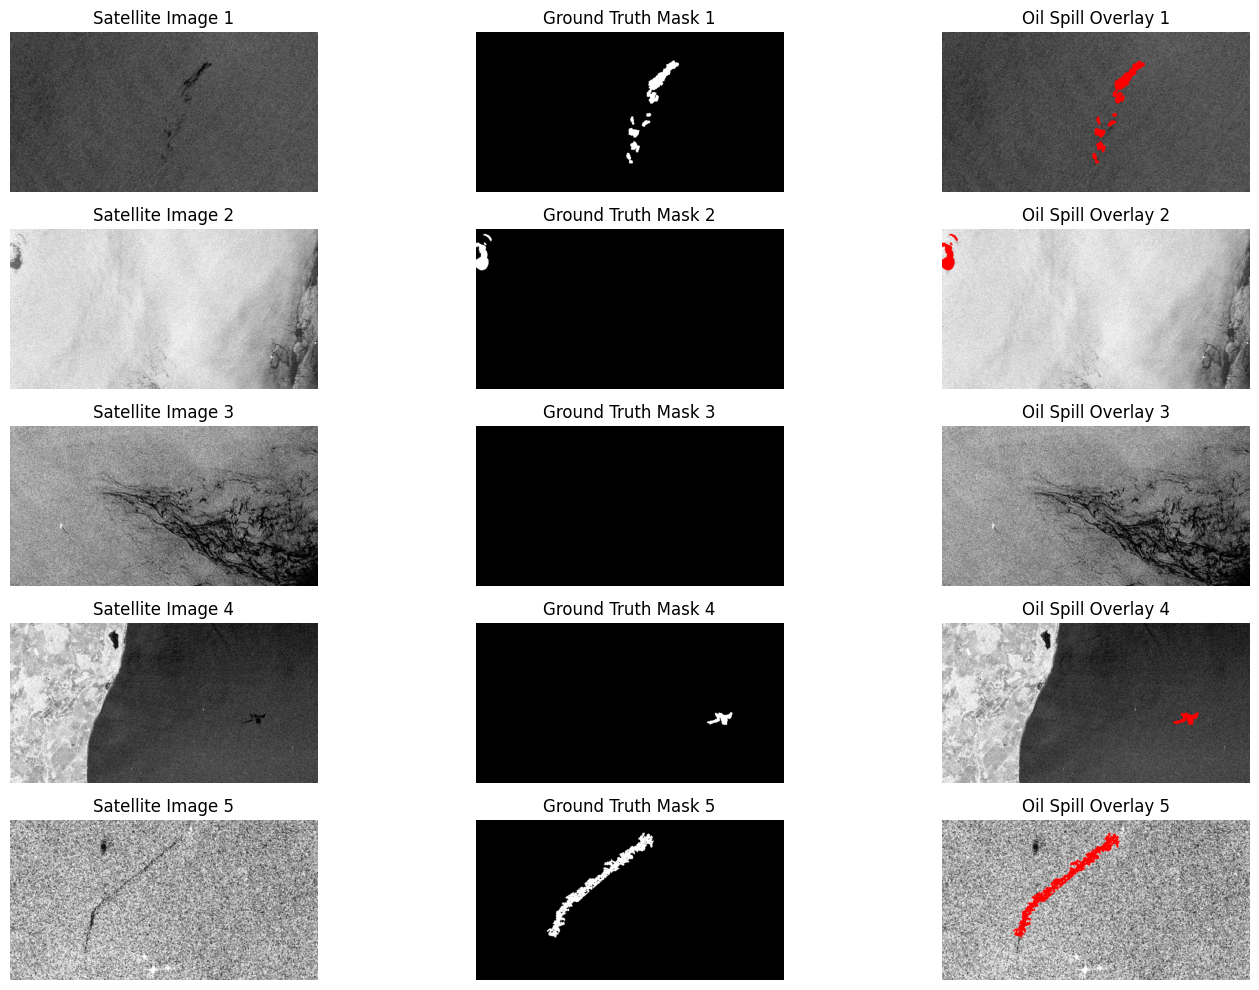

Displayed 5 satellite images with masks and oil spill overlay.


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

num_samples = 5

plt.figure(figsize=(15,10))

for i in range(num_samples):

    # Load image
    img = cv2.imread(train_imgs[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Load mask
    mask = cv2.imread(train_msks[i],0)

    # Convert mask to binary
    mask = mask/255.0
    binary_mask = (mask > 0.5).astype(np.uint8)

    # Create overlay
    overlay = img.copy()
    overlay[binary_mask == 1] = [255,0,0]   # red color for oil spill

    # Plot Original Image
    plt.subplot(num_samples,3,3*i+1)
    plt.imshow(img)
    plt.title(f"Satellite Image {i+1}")
    plt.axis("off")

    # Plot Mask
    plt.subplot(num_samples,3,3*i+2)
    plt.imshow(binary_mask,cmap="gray")
    plt.title(f"Ground Truth Mask {i+1}")
    plt.axis("off")

    # Plot Overlay
    plt.subplot(num_samples,3,3*i+3)
    plt.imshow(overlay)
    plt.title(f"Oil Spill Overlay {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Displayed 5 satellite images with masks and oil spill overlay.")

In [ ]:
mask = cv2.imread(train_msks[0],0)

mask = mask/255.0
binary_mask = (mask > 0.5).astype(np.uint8)

print("Binary Mask Unique Values:", np.unique(binary_mask))

Binary Mask Unique Values: [0 1]


In [ ]:
for i in range(10):

    mask = cv2.imread(train_msks[i],0)
    mask = mask/255.0
    binary_mask = (mask>0.5).astype(np.uint8)

    print(f"Mask {i} unique values:", np.unique(binary_mask))

Mask 0 unique values: [0 1]
Mask 1 unique values: [0 1]
Mask 2 unique values: [0]
Mask 3 unique values: [0 1]
Mask 4 unique values: [0 1]
Mask 5 unique values: [0 1]
Mask 6 unique values: [0 1]
Mask 7 unique values: [0 1]
Mask 8 unique values: [0 1]
Mask 9 unique values: [0 1]


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

foreground_pixels = 0
background_pixels = 0

for mask_path in train_msks:

    mask = cv2.imread(mask_path, 0)

    # Normalize
    mask = mask / 255.0

    # Binary threshold
    mask = (mask > 0.5).astype(np.uint8)

    # Count pixels
    foreground_pixels += np.sum(mask == 1)
    background_pixels += np.sum(mask == 0)

total_pixels = foreground_pixels + background_pixels

print("===== FOREGROUND vs BACKGROUND ANALYSIS =====")
print("Foreground Pixels (Oil Spill):", foreground_pixels)
print("Background Pixels (Ocean):", background_pixels)
print("Total Pixels:", total_pixels)

===== FOREGROUND vs BACKGROUND ANALYSIS =====
Foreground Pixels (Oil Spill): 6620252
Background Pixels (Ocean): 644192248
Total Pixels: 650812500


In [ ]:
foreground_percentage = (foreground_pixels / total_pixels) * 100
background_percentage = (background_pixels / total_pixels) * 100

print("Oil Spill Percentage:", round(foreground_percentage,2), "%")
print("Ocean Background Percentage:", round(background_percentage,2), "%")

Oil Spill Percentage: 1.02 %
Ocean Background Percentage: 98.98 %


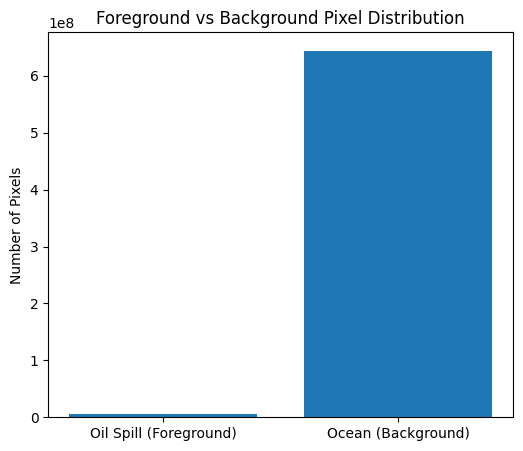

In [ ]:
labels = ["Oil Spill (Foreground)", "Ocean (Background)"]
values = [foreground_pixels, background_pixels]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.bar(labels, values)
plt.title("Foreground vs Background Pixel Distribution")
plt.ylabel("Number of Pixels")
plt.show()

In [ ]:
mask = cv2.imread(train_msks[0],0)/255
mask = (mask>0.5).astype(np.uint8)

oil_pixels = np.sum(mask==1)
total_pixels = mask.size

oil_percentage = (oil_pixels/total_pixels)*100

print("Oil Pixels:", oil_pixels)
print("Total Pixels:", total_pixels)
print("Oil Spill Percentage:", oil_percentage,"%")

Oil Pixels: 10664
Total Pixels: 812500
Oil Spill Percentage: 1.3124923076923078 %


In [ ]:
IMG_SIZE = 256

def load_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

def load_mask(path):
    mask = cv2.imread(path, 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = mask / 255.0

    # smoother threshold (important)
    mask = (mask > 0.3).astype(np.float32)
    mask = np.expand_dims(mask, -1)

    return mask

In [ ]:
X_train = np.array([load_image(x) for x in train_imgs])
Y_train = np.array([load_mask(x) for x in train_msks])

X_val = np.array([load_image(x) for x in val_imgs])
Y_val = np.array([load_mask(x) for x in val_msks])

print("Train Data Shape:",X_train.shape)
print("Train Mask Shape:",Y_train.shape)

Train Data Shape: (801, 256, 256, 3)
Train Mask Shape: (801, 256, 256, 1)


In [ ]:
# Data Augmentation
# brightness variation, and shifting to improve model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_datagen = ImageDataGenerator(

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"

)

mask_datagen = ImageDataGenerator(

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"

)

seed = 42
batch_size = 8

image_generator = image_datagen.flow(
    X_train,
    batch_size=batch_size,
    seed=seed
)

mask_generator = mask_datagen.flow(
    Y_train,
    batch_size=batch_size,
    seed=seed
)

def train_generator():

    while True:

        img = next(image_generator)
        mask = next(mask_generator)

        yield img, mask

In [ ]:
from tensorflow.keras import layers, models

def build_unet(input_shape=(256,256,3)):

    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(64,3,activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(128,3,activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256,3,activation='relu',padding='same')(p2)
    c3 = layers.Conv2D(256,3,activation='relu',padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    c4 = layers.Conv2D(512,3,activation='relu',padding='same')(p3)
    c4 = layers.Conv2D(512,3,activation='relu',padding='same')(c4)

    # Decoder
    u1 = layers.UpSampling2D()(c4)
    u1 = layers.concatenate([u1,c3])

    c5 = layers.Conv2D(256,3,activation='relu',padding='same')(u1)
    c5 = layers.Conv2D(256,3,activation='relu',padding='same')(c5)

    u2 = layers.UpSampling2D()(c5)
    u2 = layers.concatenate([u2,c2])

    c6 = layers.Conv2D(128,3,activation='relu',padding='same')(u2)
    c6 = layers.Conv2D(128,3,activation='relu',padding='same')(c6)

    u3 = layers.UpSampling2D()(c6)
    u3 = layers.concatenate([u3,c1])

    c7 = layers.Conv2D(64,3,activation='relu',padding='same')(u3)
    c7 = layers.Conv2D(64,3,activation='relu',padding='same')(c7)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c7)

    model = models.Model(inputs,outputs)

    return model

model = build_unet()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 768)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │  1,769,728 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_9[0][0]  

 Total params: 7,782,913 (29.69 MB)

 Trainable params: 7,782,913 (29.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def dice_loss(y_true, y_pred):
    smooth = 1
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true * y_pred)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)

def iou_loss(y_true, y_pred):
    smooth = 1
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return 1 - (intersection + smooth) / (union + smooth)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred) + iou_loss(y_true, y_pred)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss=combined_loss,
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator(),
    steps_per_epoch=len(X_train)//8,
    validation_data=(X_val, Y_val),
    epochs=60,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 133s 926ms/step - accuracy: 0.9353 - loss: 2.2599 - val_accuracy: 0.9357 - val_loss: 2.2198 - learning_rate: 5.0000e-05
Epoch 2/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 412ms/step - accuracy: 0.9234 - loss: 2.0681 - val_accuracy: 0.7371 - val_loss: 2.1615 - learning_rate: 5.0000e-05
Epoch 3/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 412ms/step - accuracy: 0.8915 - loss: 1.7794 - val_accuracy: 0.9190 - val_loss: 1.7177 - learning_rate: 5.0000e-05
Epoch 4/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 409ms/step - accuracy: 0.9115 - loss: 1.6080 - val_accuracy: 0.9325 - val_loss: 1.6002 - learning_rate: 5.0000e-05
Epoch 5/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 411ms/step - accuracy: 0.9052 - loss: 1.6425 - val_accuracy: 0.9313 - val_loss: 1.4027 - learning_rate: 5.0000e-05
Epoch 6/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 411ms/step - accuracy: 0.9393 - loss: 1.4628 - val_accuracy: 0.9332 - val_loss: 1.2310 - learning_rate: 5.0000e-05
Epoch 7/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 4

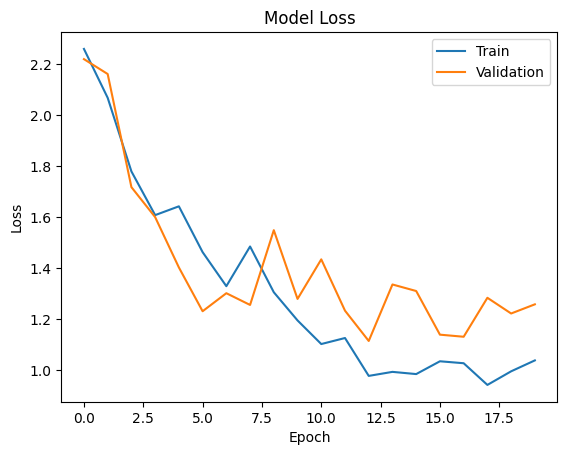

In [ ]:
#Training vs validation curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
X_test = np.array([load_image(x) for x in test_images])
Y_test = np.array([load_mask(x) for x in test_masks])

print("Test Data Shape:", X_test.shape)
print("Test Mask Shape:", Y_test.shape)

Test Data Shape: (110, 256, 256, 3)
Test Mask Shape: (110, 256, 256, 1)


In [ ]:
Y_pred = model.predict(X_test)

print("Prediction Shape:", Y_pred.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step
Prediction Shape: (110, 256, 256, 1)


In [ ]:
Y_pred_binary = (Y_pred > 0.5).astype(np.uint8)

print("Unique values in prediction:", np.unique(Y_pred_binary))

Unique values in prediction: [0 1]


In [ ]:
y_true = Y_test.flatten()
y_pred = Y_pred_binary.flatten()

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import jaccard_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)

intersection = np.sum(y_true * y_pred)
dice = (2 * intersection) / (np.sum(y_true) + np.sum(y_pred))

print("\n===== MODEL RESULTS =====")

print("Model Accuracy :", accuracy)
print("Model Precision:", precision)
print("Model Recall   :", recall)
print("Model IoU      :", iou)
print("Dice Score     :", dice)


===== MODEL RESULTS =====
Model Accuracy : 0.9782067038796165
Model Precision: 0.7577561786507896
Model Recall   : 0.7227028880936511
Model IoU      : 0.5870679980129683
Dice Score     : 0.7398145495315711


In [ ]:
# Ensure masks are binary
Y_test = (Y_test > 0).astype(np.uint8)

# Run evaluation
evaluate_threshold(model, X_test, Y_test, 0.5)
evaluate_threshold(model, X_test, Y_test, 0.4)
evaluate_threshold(model, X_test, Y_test, 0.6)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 593ms/step

Threshold: 0.5
Precision: 0.7546542715000399
Recall   : 0.7023445133986062
Dice     : 0.7275603694317128
IoU      : 0.5717838017254249
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 352ms/step

Threshold: 0.4
Precision: 0.7477702668187778
Recall   : 0.7104690968155257
Dice     : 0.7286426074365676
IoU      : 0.5731217765353273
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 358ms/step

Threshold: 0.6
Precision: 0.7617938347140893
Recall   : 0.6941260976761944
Dice     : 0.7263874474966159
IoU      : 0.570336281681248


In [ ]:
evaluate_threshold(model, X_test, Y_test, 0.7)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 368ms/step

Threshold: 0.7
Precision: 0.7698160580754325
Recall   : 0.6845131397583656
Dice     : 0.7246628998920583
IoU      : 0.5682128276762779


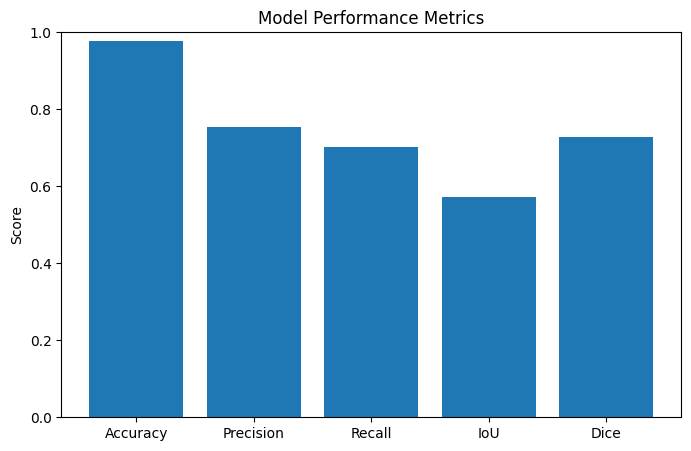

In [ ]:
import matplotlib.pyplot as plt

metrics = ['Accuracy','Precision','Recall','IoU','Dice']
values = [accuracy, precision, recall, iou, dice]

plt.figure(figsize=(8,5))
plt.bar(metrics, values)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

In [ ]:
X_test = np.array([load_image(x) for x in test_images])
Y_test = np.array([load_mask(x) for x in test_masks])

print("Test Data Shape:", X_test.shape)
print("Test Mask Shape:", Y_test.shape)

Test Data Shape: (110, 256, 256, 3)
Test Mask Shape: (110, 256, 256, 1)


In [ ]:
Y_pred = model.predict(X_test)

print("Prediction Shape:", Y_pred.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 349ms/step
Prediction Shape: (110, 256, 256, 1)


In [ ]:
Y_pred_binary = (Y_pred > 0.3).astype(np.uint8)

print("Unique values in prediction:", np.unique(Y_pred_binary))

Unique values in prediction: [0 1]


In [ ]:
import cv2

mask = cv2.medianBlur(mask.astype(np.uint8), 5)

In [ ]:
y_true = Y_test.flatten()
y_pred = Y_pred_binary.flatten()

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import jaccard_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)

intersection = np.sum(y_true * y_pred)
dice = (2 * intersection) / (np.sum(y_true) + np.sum(y_pred))

print("\n===== MODEL RESULTS =====")

print("Model Accuracy :", accuracy)
print("Model Precision:", precision)
print("Model Recall   :", recall)
print("Model IoU      :", iou)
print("Dice Score     :", dice)


===== MODEL RESULTS =====
Model Accuracy : 0.9771580089222301
Model Precision: 0.7404219184468606
Model Recall   : 0.7194187574014276
Model IoU      : 0.5745170692381631
Dice Score     : 0.7297692485685731


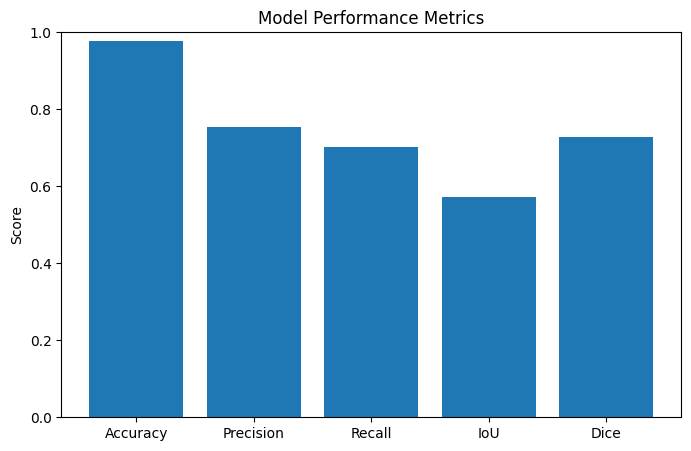

In [ ]:
import matplotlib.pyplot as plt

metrics = ['Accuracy','Precision','Recall','IoU','Dice']
values = [accuracy, precision, recall, iou, dice]

plt.figure(figsize=(8,5))
plt.bar(metrics, values)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

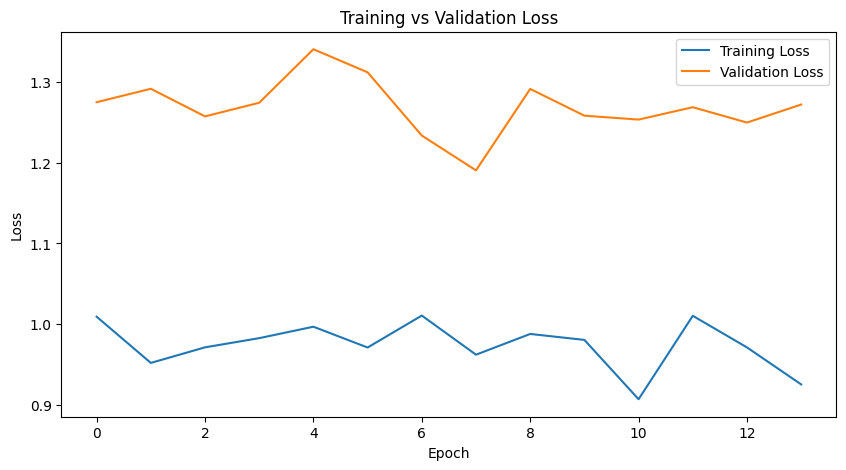

In [ ]:
#Plot Training vs Validation Performance
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

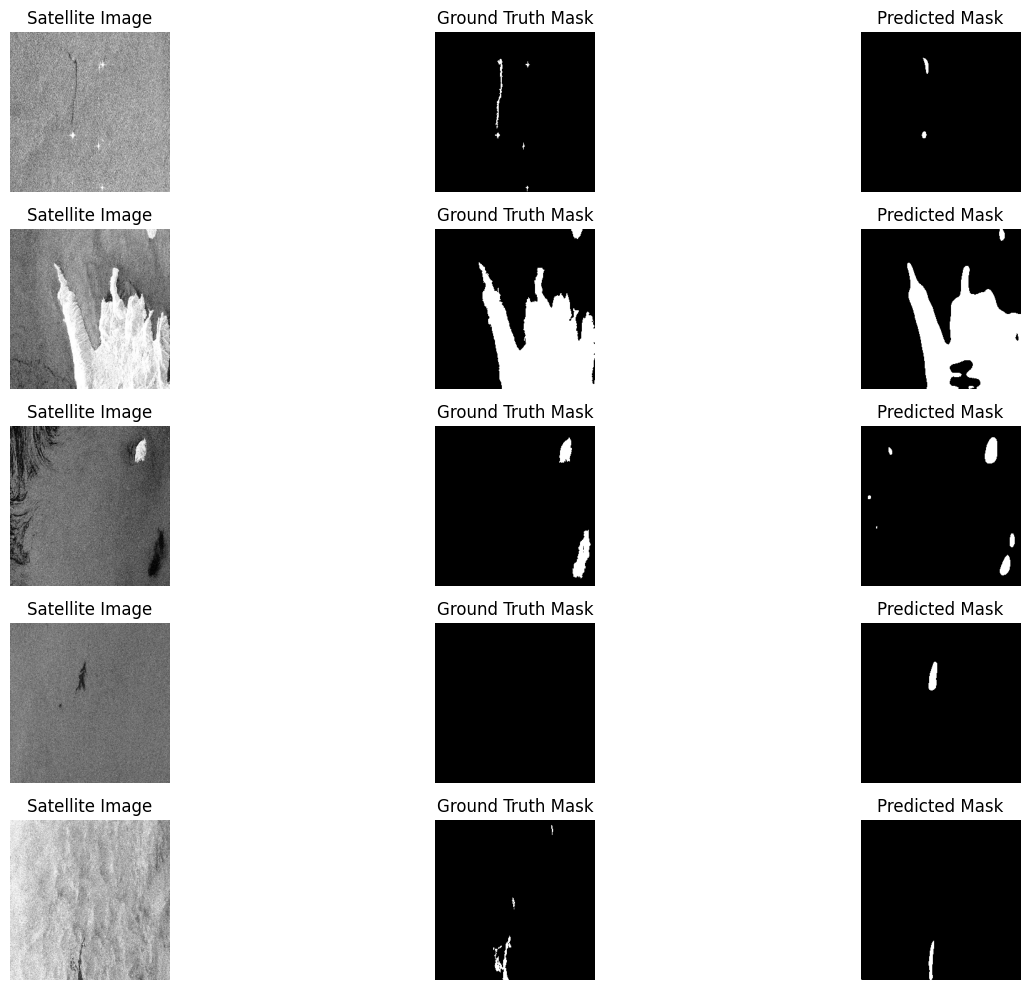

In [ ]:
#Side-by-Side Comparison
num_samples = 5

plt.figure(figsize=(15,10))

for i in range(num_samples):

    img = X_test[i]
    true_mask = Y_test[i].squeeze()
    pred_mask = Y_pred_binary[i].squeeze()

    # Original Image
    plt.subplot(num_samples,3,3*i+1)
    plt.imshow(img)
    plt.title("Satellite Image")
    plt.axis("off")

    # Ground Truth Mask
    plt.subplot(num_samples,3,3*i+2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # Predicted Mask
    plt.subplot(num_samples,3,3*i+3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

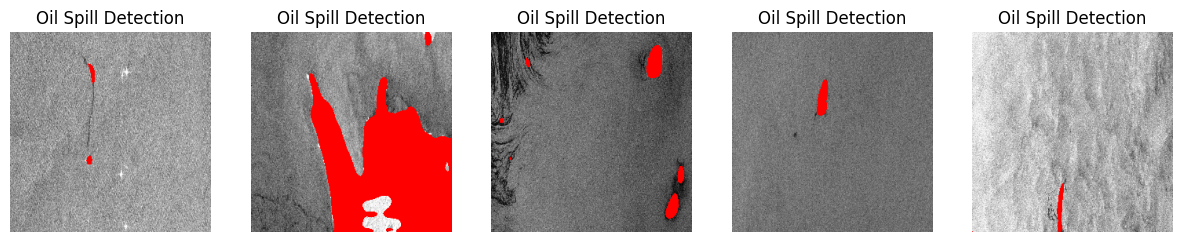

In [ ]:
#Overlay Segmentation Mask on Image
plt.figure(figsize=(15,8))

for i in range(5):

    img = X_test[i]
    pred_mask = Y_pred_binary[i].squeeze()

    overlay = img.copy()

    # highlight oil spill in red
    overlay[pred_mask==1] = [1,0,0]

    plt.subplot(1,5,i+1)
    plt.imshow(overlay)
    plt.title("Oil Spill Detection")
    plt.axis("off")

plt.show()

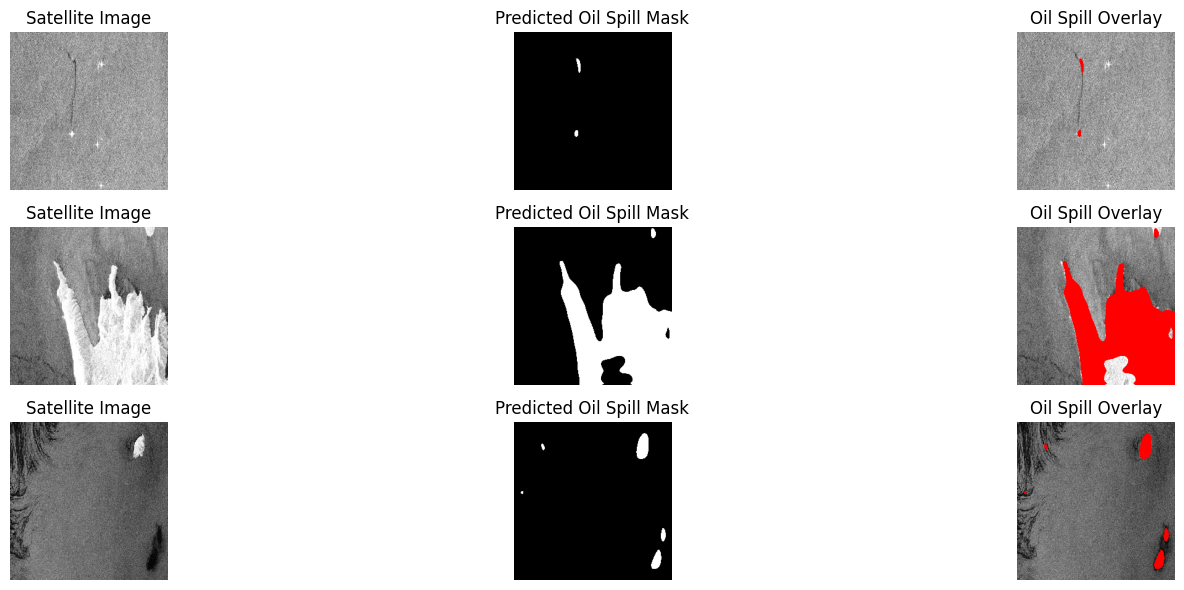

In [ ]:
#Visual Summary for Reports
plt.figure(figsize=(18,6))

for i in range(3):

    img = X_test[i]
    pred_mask = Y_pred_binary[i].squeeze()

    overlay = img.copy()
    overlay[pred_mask==1] = [1,0,0]

    plt.subplot(3,3,3*i+1)
    plt.imshow(img)
    plt.title("Satellite Image")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Oil Spill Mask")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(overlay)
    plt.title("Oil Spill Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/best_model.h5")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
model.save("final_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "final_model.h5",
    custom_objects={
        "combined_loss": combined_loss
    }
)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
from google.colab import files
files.download('final_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>